# Ejemplo de Self-Organizing Map (SOM) con el dataset Wine

## Objetivos

En este notebook utilizaremos el dataset Wine de `scikit-learn` para aplicar un Self-Organizing Map (SOM) como método de representación no supervisada y posteriormente obtener una partición explícita mediante K-Means sobre los prototipos del mapa.

Se conserva la estructura utilizada en los demás ejemplos del curso:

1. exploración del dataset;
2. análisis de distribución y correlación;
3. estandarización;
4. entrenamiento del método;
5. evaluación de distintas combinaciones de hiperparámetros;
6. selección mediante ranking multicriterio;
7. visualización e interpretación de los clusters;
8. evaluación externa usando las clases reales únicamente al final.


## 1. Importación de librerías


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)
from scipy.stats import shapiro

try:
    from minisom import MiniSom
except ImportError:
    !pip -q install minisom
    from minisom import MiniSom

pd.set_option("display.max_columns", None)


## 2. Carga del dataset

`load_wine()` contiene 178 observaciones, 13 características químicas numéricas y tres clases reales. Durante el ajuste de GMM trabajaremos únicamente con $X$.

In [2]:
wine = load_wine()

X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Series(wine.target, name="target")

print("Dimensiones de X:", X.shape)
print("Número de clases reales:", y.nunique())
X.head()

Dimensiones de X: (178, 13)
Número de clases reales: 3


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


## 3. Exploración inicial

Revisaremos valores faltantes, estadísticos descriptivos, diferencias de escala, distribución y correlaciones antes de ajustar el modelo.

In [3]:
print("Valores faltantes por variable:")
display(X.isna().sum().to_frame("faltantes"))

print("\nEstadísticos descriptivos:")
display(X.describe().T)

Valores faltantes por variable:


,faltantes
alcohol,0
malic_acid,0
ash,0
alcalinity_of_ash,0
magnesium,0
total_phenols,0
flavanoids,0
nonflavanoid_phenols,0
proanthocyanins,0
color_intensity,0



Estadísticos descriptivos:


,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


### 3.1. Comparación de escalas

In [4]:
ranges = pd.DataFrame({
    "min": X.min(),
    "max": X.max(),
    "rango": X.max() - X.min(),
    "media": X.mean(),
    "std": X.std()
}).sort_values("rango", ascending=False)

ranges

,min,max,rango,media,std
proline,278.00,1680.00,1402.00,746.893258,314.907474
magnesium,70.00,162.00,92.00,99.741573,14.282484
alcalinity_of_ash,10.60,30.00,19.40,19.494944,3.339564
color_intensity,1.28,13.00,11.72,5.058090,2.318286
malic_acid,0.74,5.80,5.06,2.336348,1.117146
flavanoids,0.34,5.08,4.74,2.029270,0.998859
alcohol,11.03,14.83,3.80,13.000618,0.811827
proanthocyanins,0.41,3.58,3.17,1.590899,0.572359
total_phenols,0.98,3.88,2.90,2.295112,0.625851
od280/od315_of_diluted_wines,1.27,4.00,2.73,2.611685,0.709990


Las variables presentan escalas muy diferentes. Como SOM utiliza distancias entre las observaciones y los vectores de pesos de las neuronas, la estandarización es necesaria para evitar que las variables de mayor escala dominen el entrenamiento.


### 3.2. Distribución de las variables: decisión entre Pearson y Spearman

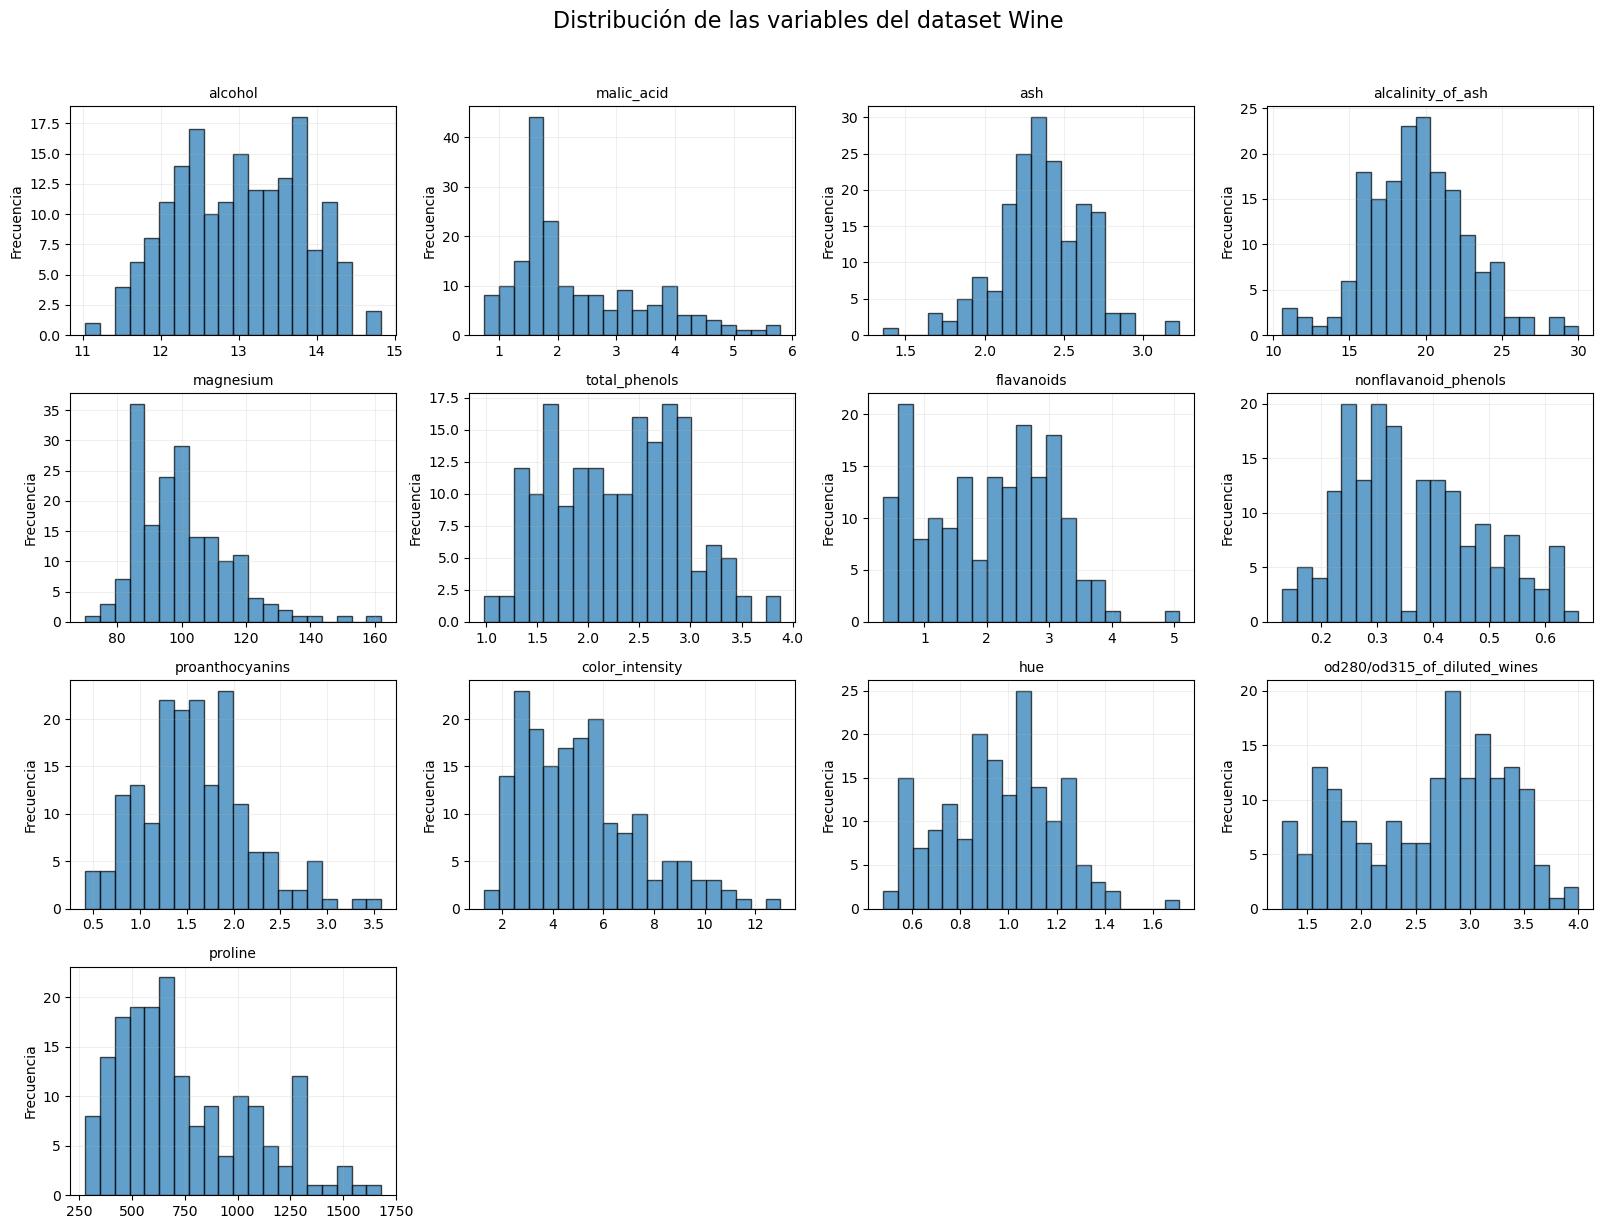

In [5]:
# Variables numéricas del dataset
features = X.columns

n_cols = 4
n_rows = 4

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(X[col], bins=20, edgecolor="black", alpha=0.7)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Frecuencia")
    axes[i].grid(alpha=0.2)

# Ocultar subplots sobrantes
for j in range(len(features), len(axes)):
    axes[j].axis("off")

plt.suptitle(
    "Distribución de las variables del dataset Wine",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

In [6]:
normality_rows = []

for variable in X.columns:
    stat, p_value = shapiro(X[variable])
    normality_rows.append({
        "variable": variable,
        "W": stat,
        "p_value": p_value,
        "¿No se rechaza normalidad?": p_value >= 0.05
    })

normality = pd.DataFrame(normality_rows).set_index("variable")
normality.round(4)

,W,p_value,¿No se rechaza normalidad?
variable,,,
alcohol,0.9818,0.0200,False
malic_acid,0.8888,0.0000,False
ash,0.9839,0.0387,False
alcalinity_of_ash,0.9902,0.2639,True
magnesium,0.9383,0.0000,False
total_phenols,0.9767,0.0044,False
flavanoids,0.9545,0.0000,False
nonflavanoid_phenols,0.9625,0.0001,False
proanthocyanins,0.9807,0.0145,False


Con $\alpha=0.05$, la gran mayoría de variables del Wine rechaza normalidad individual. Por ello, para el análisis exploratorio utilizaremos **Spearman**. Esto no impide utilizar GMM: el supuesto gaussiano del GMM se refiere a la distribución **multivariada dentro de cada componente**, no a que cada variable marginal del dataset completo deba ser normal.

Método de correlación seleccionado: Spearman
Variables que no rechazan normalidad: 1 de 13


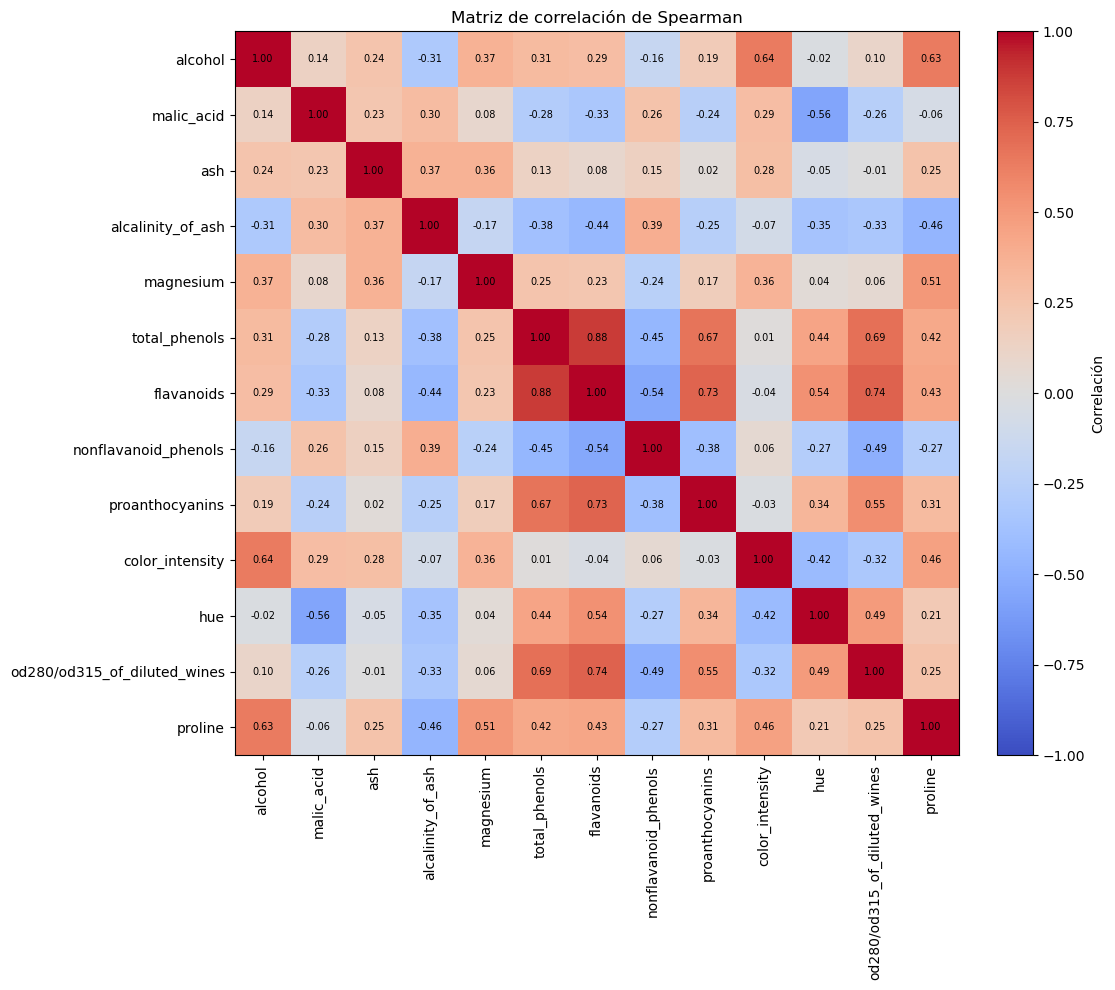

In [7]:
# Regla didáctica para este EDA:
# - Pearson si todas las variables no rechazan normalidad a alpha=0.05.
# - Spearman si al menos una variable presenta evidencia de no normalidad.
# En Wine, la gran mayoría rechaza normalidad, por lo que se utiliza Spearman.

all_normal = normality["¿No se rechaza normalidad?"].all()
corr_method = "pearson" if all_normal else "spearman"

print("Método de correlación seleccionado:", corr_method.capitalize())
print(
    "Variables que no rechazan normalidad:",
    int(normality["¿No se rechaza normalidad?"].sum()),
    "de", X.shape[1]
)

corr = X.corr(method=corr_method)

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}",
                ha="center", va="center", fontsize=7)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Correlación")
ax.set_title(f"Matriz de correlación de {corr_method.capitalize()}")
plt.tight_layout()
plt.show()

### 3.3. Pares de variables con mayor correlación absoluta

In [8]:
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
strong_pairs = (
    upper.stack()
         .rename("correlacion")
         .reset_index()
         .rename(columns={"level_0": "variable_1", "level_1": "variable_2"})
)
strong_pairs["abs_correlacion"] = strong_pairs["correlacion"].abs()
strong_pairs = strong_pairs.sort_values("abs_correlacion", ascending=False)
strong_pairs.head(10).drop(columns="abs_correlacion").round(3)

,variable_1,variable_2,correlacion
50,total_phenols,flavanoids,0.879
61,flavanoids,od280/od315_of_diluted_wines,0.742
58,flavanoids,proanthocyanins,0.730
55,total_phenols,od280/od315_of_diluted_wines,0.687
52,total_phenols,proanthocyanins,0.667
8,alcohol,color_intensity,0.635
11,alcohol,proline,0.634
20,malic_acid,hue,-0.560
70,proanthocyanins,od280/od315_of_diluted_wines,0.554
57,flavanoids,nonflavanoid_phenols,-0.544


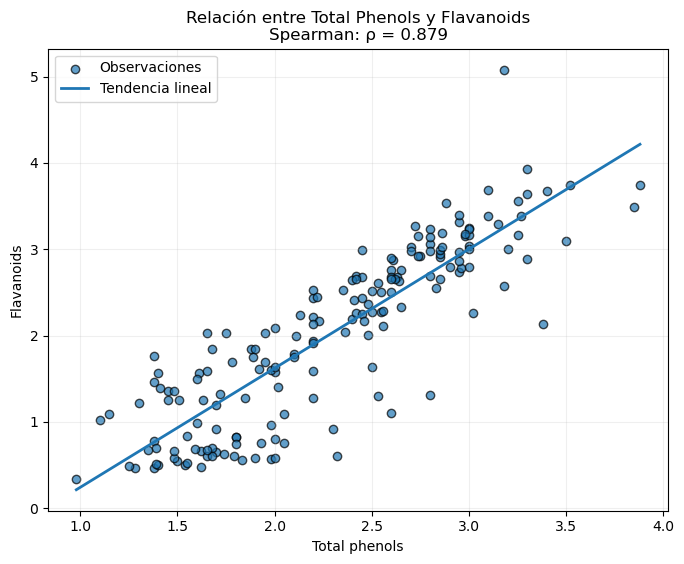

In [9]:
var1 = "total_phenols"
var2 = "flavanoids"
method = "Spearman"
symbol = "ρ"

corr_value = strong_pairs.loc[
    ((strong_pairs["variable_1"] == var1) & (strong_pairs["variable_2"] == var2)) |
    ((strong_pairs["variable_1"] == var2) & (strong_pairs["variable_2"] == var1)),
    "correlacion"
].iloc[0]

plt.figure(figsize=(8, 6))

plt.scatter(
    X[var1],
    X[var2],
    alpha=0.7,
    edgecolor="black",
    label="Observaciones"
)

m, b = np.polyfit(X[var1], X[var2], 1)
x_line = np.linspace(X[var1].min(), X[var1].max(), 100)
y_line = m * x_line + b

plt.plot(
    x_line,
    y_line,
    linewidth=2,
    label="Tendencia lineal"
)

plt.xlabel("Total phenols")
plt.ylabel("Flavanoids")

plt.title(
    f"Relación entre Total Phenols y Flavanoids\n"
    f"{method}: {symbol} = {corr_value:.3f}"
)

plt.legend()
plt.grid(alpha=0.2)
plt.show()


## 4. Preprocesamiento

In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled_df.describe().T[["mean", "std", "min", "max"]]

,mean,std,min,max
alcohol,7.943708e-15,1.002821,-2.434235,2.259772
malic_acid,3.592632e-16,1.002821,-1.432983,3.109192
ash,-4.066660e-15,1.002821,-3.679162,3.156325
alcalinity_of_ash,-7.983626e-17,1.002821,-2.671018,3.154511
magnesium,-7.983626e-17,1.002821,-2.088255,4.371372
total_phenols,-3.991813e-17,1.002821,-2.107246,2.539515
flavanoids,9.979533e-16,1.002821,-1.695971,3.062832
nonflavanoid_phenols,-5.588538e-16,1.002821,-1.868234,2.402403
proanthocyanins,-1.656602e-15,1.002821,-2.069034,3.485073
color_intensity,-3.442939e-16,1.002821,-1.634288,3.435432


Después de `StandardScaler`, cada variable queda aproximadamente centrada en 0 y con desviación estándar cercana a 1.

## 5. Self-Organizing Map (SOM)

SOM organiza observaciones multidimensionales sobre una rejilla de neuronas. Cada neurona $$j$$ posee un vector de pesos:

$$
\mathbf{w}_j \in \mathbb{R}^d
$$

Para cada observación $$\mathbf{x}_i$$, se identifica la neurona más cercana o Best Matching Unit (BMU):

$$
c=\arg\min_j \|\mathbf{x}_i-\mathbf{w}_j\|
$$

Luego se actualizan la BMU y sus neuronas vecinas. Al finalizar, los vectores $$\mathbf{w}_j$$ funcionan como prototipos organizados topológicamente.

SOM no produce necesariamente una partición explícita en \(K\) clusters. En este ejemplo, después de entrenar el SOM, aplicaremos K-Means sobre los prototipos aprendidos y cada observación heredará el cluster asignado a su BMU.


## 6. Evaluación de configuraciones de hiperparámetros

Se explorarán distintas combinaciones de:

- tamaño de la rejilla: $$5\times5$$ y $$7\times7$$;
- radio inicial de vecindad $$\sigma$$: 0.5, 1.0 y 1.5;
- tasa de aprendizaje inicial $$alpha$$: 0.1, 0.3 y 0.5;
- número de clusters finales $$K$$: 2, 3, 4 y 5.

Para mantener el ejemplo alineado con la formulación explicada en clase se fija:

- `neighborhood_function="gaussian"`;
- topología rectangular;
- 2000 iteraciones de entrenamiento;
- inicialización aleatoria reproducible con `random_seed=42`.

El número $$K$$ corresponde al K-Means aplicado después del SOM, no al número de neuronas del mapa.


In [11]:
def clustering_sse(X_array, labels):
    sse = 0.0
    for cluster_id in np.unique(labels):
        points = X_array[labels == cluster_id]
        centroid = points.mean(axis=0)
        sse += np.sum((points - centroid) ** 2)
    return sse


def labels_from_som_and_kmeans(som, X_array, n_clusters, random_state=42):
    weights = som.get_weights()
    map_x, map_y, n_features = weights.shape

    prototypes = weights.reshape(map_x * map_y, n_features)

    kmeans = KMeans(
        n_clusters=n_clusters,
        n_init=20,
        random_state=random_state
    )
    kmeans.fit(prototypes)

    neuron_clusters = kmeans.labels_.reshape(map_x, map_y)

    labels = np.array([
        neuron_clusters[som.winner(x)]
        for x in X_array
    ])

    return labels, kmeans, neuron_clusters


In [12]:
map_sizes = [(5, 5), (7, 7)]
sigma_values = [0.5, 1.0, 1.5]
learning_rates = [0.1, 0.3, 0.5]
k_values = [2, 3, 4, 5]

num_iterations = 2000

results = []
models = {}

for map_x, map_y in map_sizes:
    for sigma in sigma_values:
        for learning_rate in learning_rates:

            som = MiniSom(
                x=map_x,
                y=map_y,
                input_len=X_scaled.shape[1],
                sigma=sigma,
                learning_rate=learning_rate,
                neighborhood_function="gaussian",
                topology="rectangular",
                random_seed=42
            )

            som.train_random(
                X_scaled,
                num_iteration=num_iterations
            )

            for k in k_values:

                labels, kmeans, neuron_clusters = labels_from_som_and_kmeans(
                    som,
                    X_scaled,
                    n_clusters=k,
                    random_state=42
                )

                key = (map_x, map_y, sigma, learning_rate, k)

                models[key] = {
                    "som": som,
                    "kmeans": kmeans,
                    "neuron_clusters": neuron_clusters,
                    "labels": labels
                }

                results.append({
                    "mapa": f"{map_x}x{map_y}",
                    "map_x": map_x,
                    "map_y": map_y,
                    "sigma": sigma,
                    "learning_rate": learning_rate,
                    "k": k,
                    "SSE ↓": clustering_sse(X_scaled, labels),
                    "Silhouette ↑": silhouette_score(X_scaled, labels),
                    "Davies-Bouldin ↓": davies_bouldin_score(X_scaled, labels),
                    "Calinski-Harabasz ↑": calinski_harabasz_score(X_scaled, labels)
                })

results = pd.DataFrame(results)
results.round(3)


C:\Users\Unimagdalena\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] El sistema no puede encontrar el archivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Unimagdalena\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\Unimagdalena\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Unimagdalena\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
 

,mapa,map_x,map_y,sigma,learning_rate,k,SSE ↓,Silhouette ↑,Davies-Bouldin ↓,Calinski-Harabasz ↑
0,5x5,5,5,0.5,0.1,2,1670.988,0.267,1.422,67.727
1,5x5,5,5,0.5,0.1,3,1310.045,0.274,1.441,67.056
2,5x5,5,5,0.5,0.1,4,1270.796,0.247,1.249,47.613
3,5x5,5,5,0.5,0.1,5,1191.606,0.260,1.184,40.738
4,5x5,5,5,0.5,0.3,2,1687.010,0.252,1.550,65.412
...,...,...,...,...,...,...,...,...,...,...
67,7x7,7,7,1.5,0.3,5,1119.607,0.246,1.670,46.139
68,7x7,7,7,1.5,0.5,2,1674.723,0.259,1.508,67.183
69,7x7,7,7,1.5,0.5,3,1297.090,0.274,1.409,68.599
70,7x7,7,7,1.5,0.5,4,1206.509,0.229,1.800,53.240


### 6.1. Visualización de las métricas

Como existen varias combinaciones de hiperparámetros, se muestran las métricas frente a \(K\) separando los resultados por tamaño de mapa. Cada línea corresponde a una combinación de \(\sigma\) y tasa de aprendizaje.


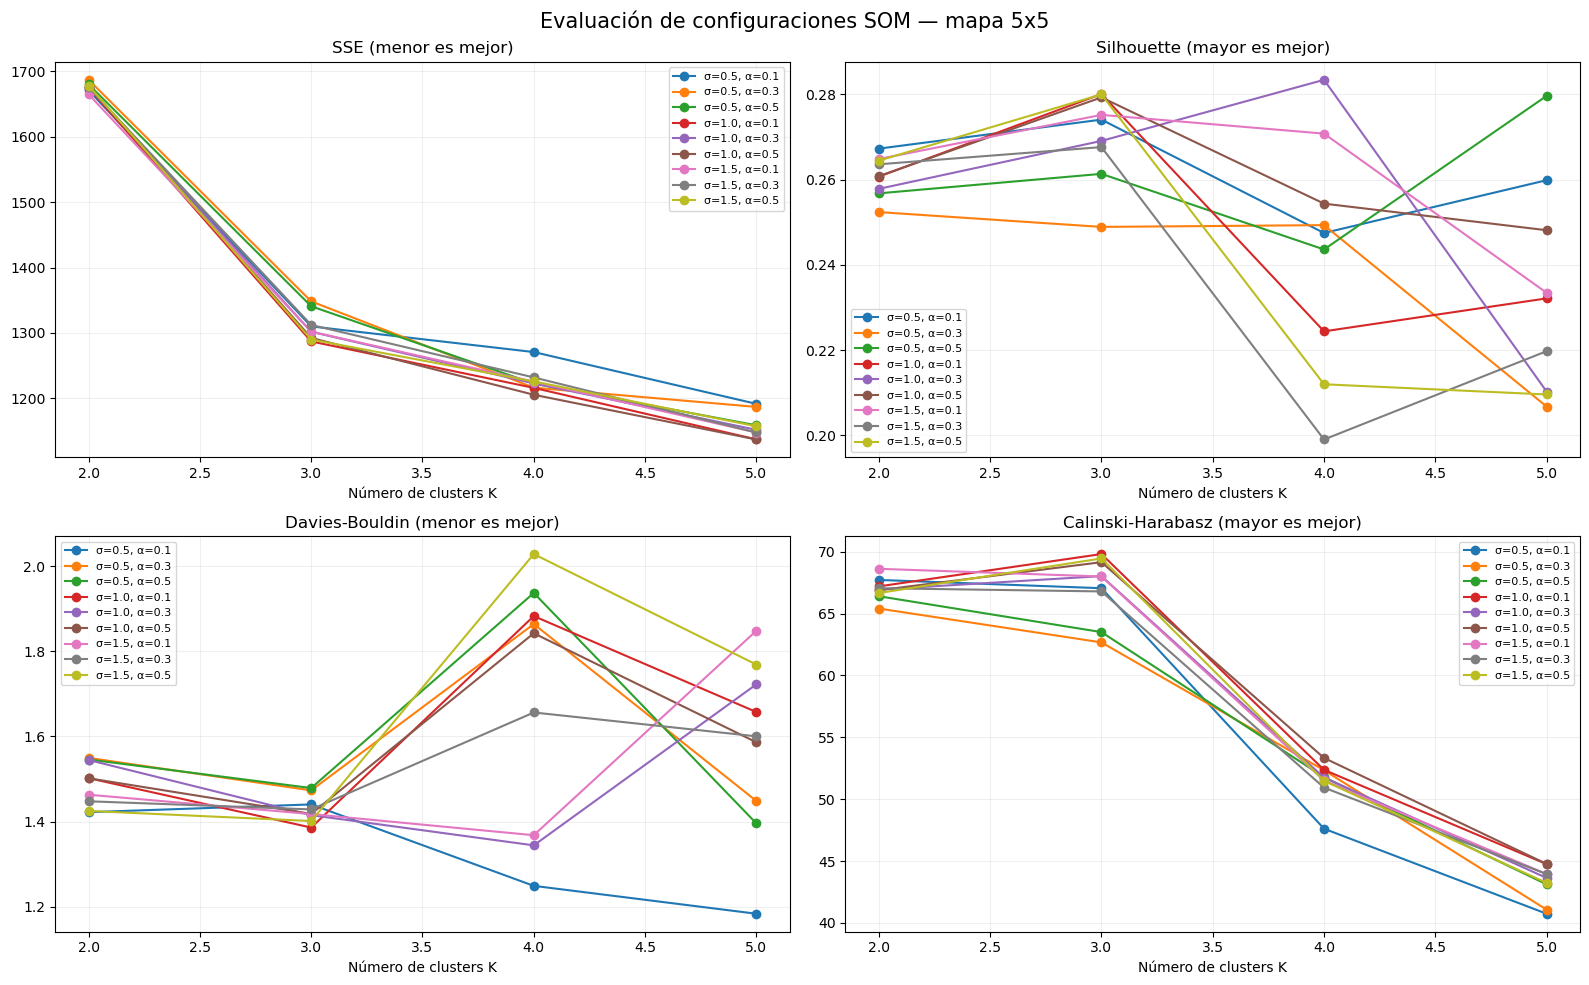

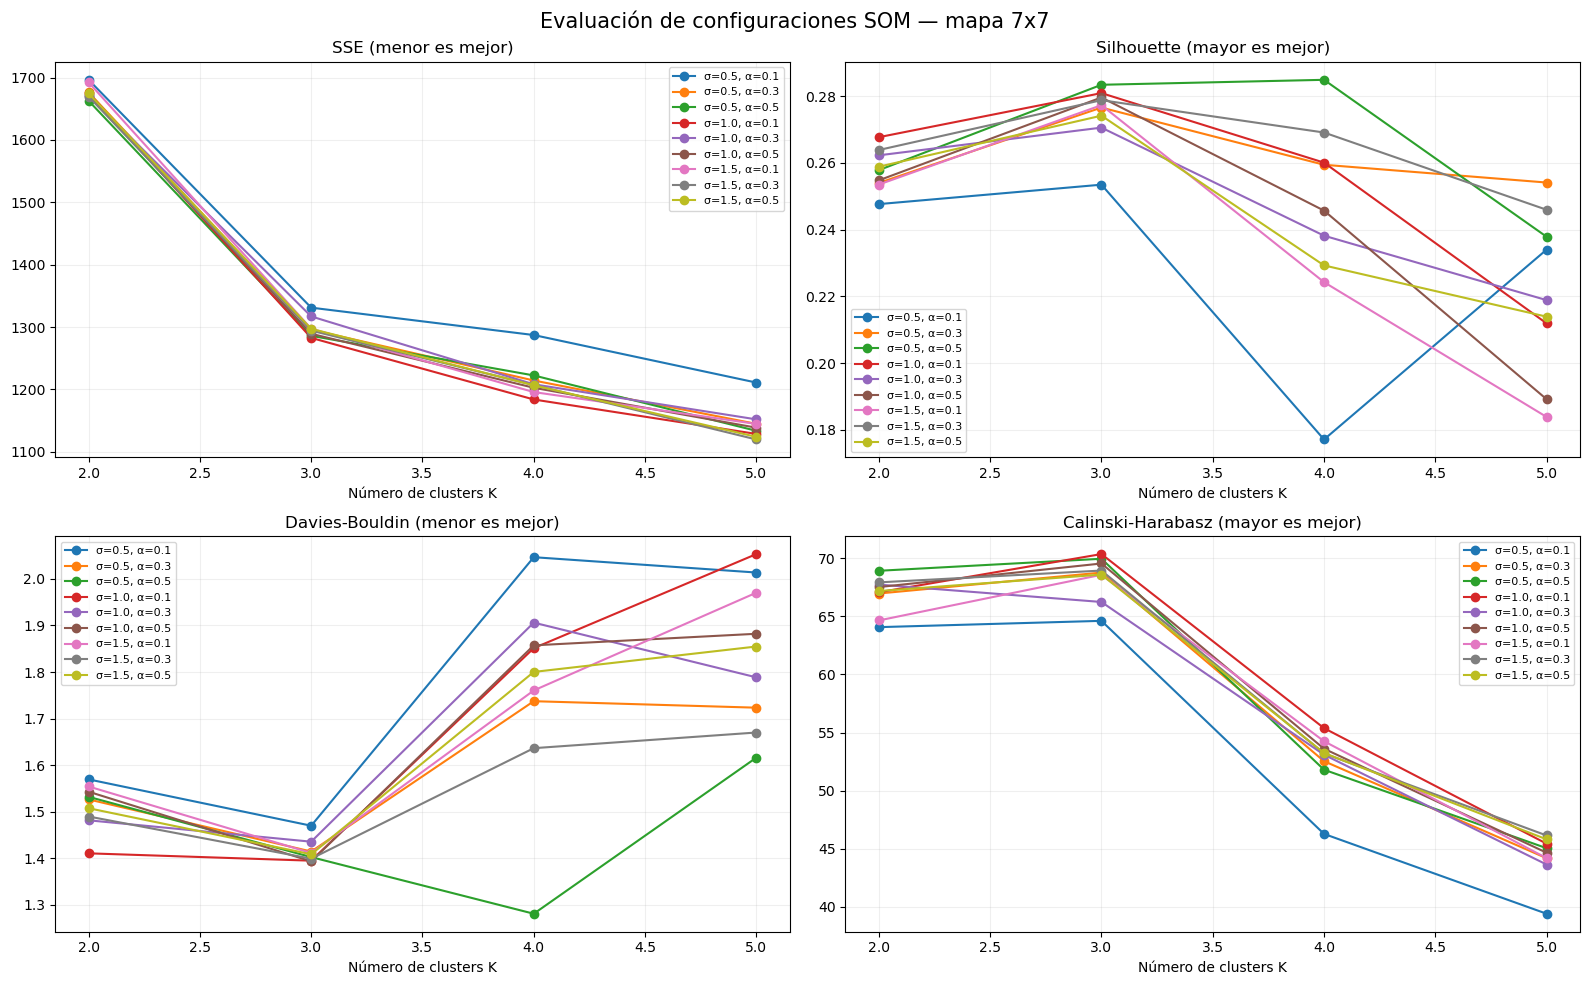

In [13]:
for map_name in results["mapa"].unique():

    subset_map = results[results["mapa"] == map_name]

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    for (sigma, lr), subset in subset_map.groupby(["sigma", "learning_rate"]):
        label = f"σ={sigma}, α={lr}"

        axes[0, 0].plot(
            subset["k"], subset["SSE ↓"],
            marker="o", label=label
        )

        axes[0, 1].plot(
            subset["k"], subset["Silhouette ↑"],
            marker="o", label=label
        )

        axes[1, 0].plot(
            subset["k"], subset["Davies-Bouldin ↓"],
            marker="o", label=label
        )

        axes[1, 1].plot(
            subset["k"], subset["Calinski-Harabasz ↑"],
            marker="o", label=label
        )

    axes[0, 0].set_title("SSE (menor es mejor)")
    axes[0, 1].set_title("Silhouette (mayor es mejor)")
    axes[1, 0].set_title("Davies-Bouldin (menor es mejor)")
    axes[1, 1].set_title("Calinski-Harabasz (mayor es mejor)")

    for ax in axes.ravel():
        ax.set_xlabel("Número de clusters K")
        ax.grid(alpha=0.2)
        ax.legend(fontsize=8)

    fig.suptitle(f"Evaluación de configuraciones SOM — mapa {map_name}", fontsize=15)
    plt.tight_layout()
    plt.show()


### 6.2. Ranking multicriterio

Cada configuración recibe una posición según:

- Silhouette: mayor es mejor;
- Davies–Bouldin: menor es mejor;
- Calinski–Harabasz: mayor es mejor;
- SSE: menor es mejor.

La suma de posiciones produce un ranking global:

$$
Rank_{total} =
Rank_{Silhouette} +
Rank_{DB} +
Rank_{CH} +
Rank_{SSE}
$$

La mejor configuración es la que obtiene el menor `Rank_Total`.


In [14]:
ranking = results.copy()

ranking["Rank_Silhouette"] = ranking["Silhouette ↑"].rank(
    ascending=False,
    method="min"
)

ranking["Rank_CH"] = ranking["Calinski-Harabasz ↑"].rank(
    ascending=False,
    method="min"
)

ranking["Rank_DB"] = ranking["Davies-Bouldin ↓"].rank(
    ascending=True,
    method="min"
)

ranking["Rank_SSE"] = ranking["SSE ↓"].rank(
    ascending=True,
    method="min"
)

ranking["Rank_Total"] = (
    ranking["Rank_Silhouette"]
    + ranking["Rank_DB"]
    + ranking["Rank_CH"]
    + ranking["Rank_SSE"]
)

ranking = (
    ranking
    .sort_values(
        ["Rank_Total", "Silhouette ↑"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)

ranking["Posición"] = ranking.index + 1

ranking[
    [
        "Posición",
        "mapa",
        "sigma",
        "learning_rate",
        "k",
        "SSE ↓",
        "Silhouette ↑",
        "Davies-Bouldin ↓",
        "Calinski-Harabasz ↑",
        "Rank_Total"
    ]
].head(20).round(3)


,Posición,mapa,sigma,learning_rate,k,SSE ↓,Silhouette ↑,Davies-Bouldin ↓,Calinski-Harabasz ↑,Rank_Total
0,1,7x7,1.0,0.1,3,1282.570,0.281,1.395,70.367,49.0
1,2,5x5,1.0,0.1,3,1287.055,0.280,1.386,69.817,52.0
2,3,7x7,0.5,0.5,3,1285.864,0.283,1.403,69.962,54.0
3,4,7x7,1.0,0.5,3,1289.196,0.280,1.394,69.555,59.0
4,5,5x5,1.5,0.5,3,1289.967,0.280,1.402,69.461,63.0
5,6,7x7,1.5,0.3,3,1294.211,0.279,1.399,68.947,70.0
6,7,5x5,1.0,0.5,3,1292.445,0.279,1.418,69.160,76.0
7,8,7x7,0.5,0.5,4,1222.327,0.285,1.281,51.800,80.0
8,9,7x7,0.5,0.3,3,1295.647,0.277,1.415,68.773,81.0
9,10,7x7,1.5,0.5,3,1297.090,0.274,1.409,68.599,83.0


### 6.3. Selección de la mejor configuración según el ranking


In [15]:
best_row = ranking.iloc[0]

selected_map_x = int(best_row["map_x"])
selected_map_y = int(best_row["map_y"])
selected_sigma = float(best_row["sigma"])
selected_learning_rate = float(best_row["learning_rate"])
selected_k = int(best_row["k"])

selected_key = (
    selected_map_x,
    selected_map_y,
    selected_sigma,
    selected_learning_rate,
    selected_k
)

selected_info = models[selected_key]

selected_som = selected_info["som"]
selected_kmeans = selected_info["kmeans"]
selected_neuron_clusters = selected_info["neuron_clusters"]
selected_labels = selected_info["labels"]

print("Mejor configuración según ranking multicriterio")
print("Mapa:", f"{selected_map_x}x{selected_map_y}")
print("sigma:", selected_sigma)
print("learning_rate:", selected_learning_rate)
print("Número de clusters K:", selected_k)

print("\nMétricas:")
print("SSE:", round(best_row["SSE ↓"], 3))
print("Silhouette:", round(best_row["Silhouette ↑"], 3))
print("Davies-Bouldin:", round(best_row["Davies-Bouldin ↓"], 3))
print("Calinski-Harabasz:", round(best_row["Calinski-Harabasz ↑"], 3))
print("Rank total:", best_row["Rank_Total"])

print("\nDistribución de clusters:")
print(pd.Series(selected_labels).value_counts().sort_index())


Mejor configuración según ranking multicriterio
Mapa: 7x7
sigma: 1.0
learning_rate: 0.1
Número de clusters K: 3

Métricas:
SSE: 1282.57
Silhouette: 0.281
Davies-Bouldin: 1.395
Calinski-Harabasz: 70.367
Rank total: 49.0

Distribución de clusters:
0    63
1    65
2    50
Name: count, dtype: int64


## 7. Distribución de observaciones en la rejilla SOM

Cada observación se asigna a su BMU. El siguiente mapa muestra cuántas observaciones fueron representadas por cada neurona.


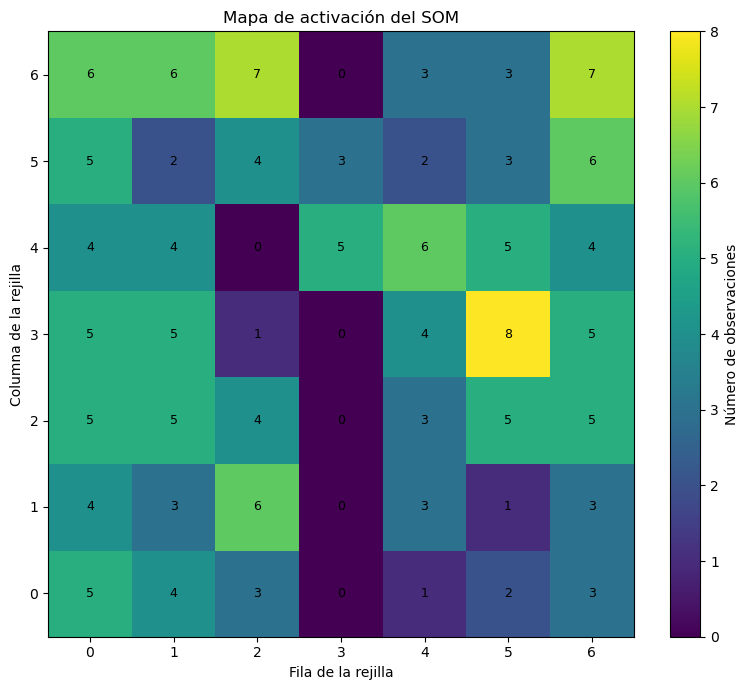

In [16]:
activation_map = selected_som.activation_response(X_scaled)

plt.figure(figsize=(8, 7))
plt.imshow(activation_map.T, origin="lower", aspect="auto")
plt.colorbar(label="Número de observaciones")

for i in range(selected_map_x):
    for j in range(selected_map_y):
        plt.text(
            i, j,
            int(activation_map[i, j]),
            ha="center",
            va="center",
            fontsize=9
        )

plt.xlabel("Fila de la rejilla")
plt.ylabel("Columna de la rejilla")
plt.title("Mapa de activación del SOM")
plt.tight_layout()
plt.show()


## 8. U-Matrix

La U-Matrix representa las distancias entre los prototipos de neuronas vecinas:

- valores pequeños sugieren regiones homogéneas;
- valores altos sugieren posibles fronteras entre regiones del mapa.


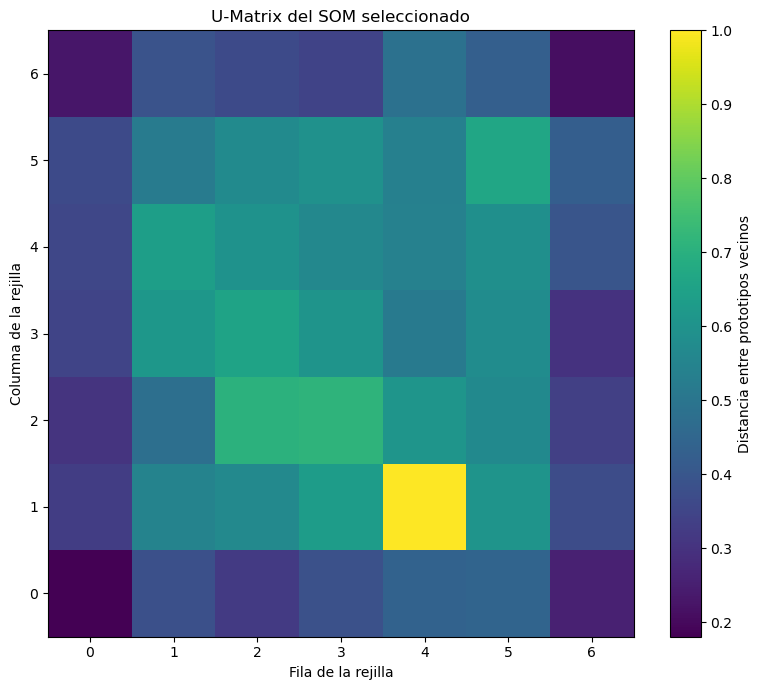

In [17]:
u_matrix = selected_som.distance_map()

plt.figure(figsize=(8, 7))
plt.imshow(u_matrix.T, origin="lower", aspect="auto")
plt.colorbar(label="Distancia entre prototipos vecinos")

plt.xlabel("Fila de la rejilla")
plt.ylabel("Columna de la rejilla")
plt.title("U-Matrix del SOM seleccionado")
plt.tight_layout()
plt.show()


## 9. Clusters sobre la rejilla SOM

K-Means se aplicó sobre los vectores de pesos de las neuronas. El siguiente mapa muestra el cluster asignado a cada neurona.


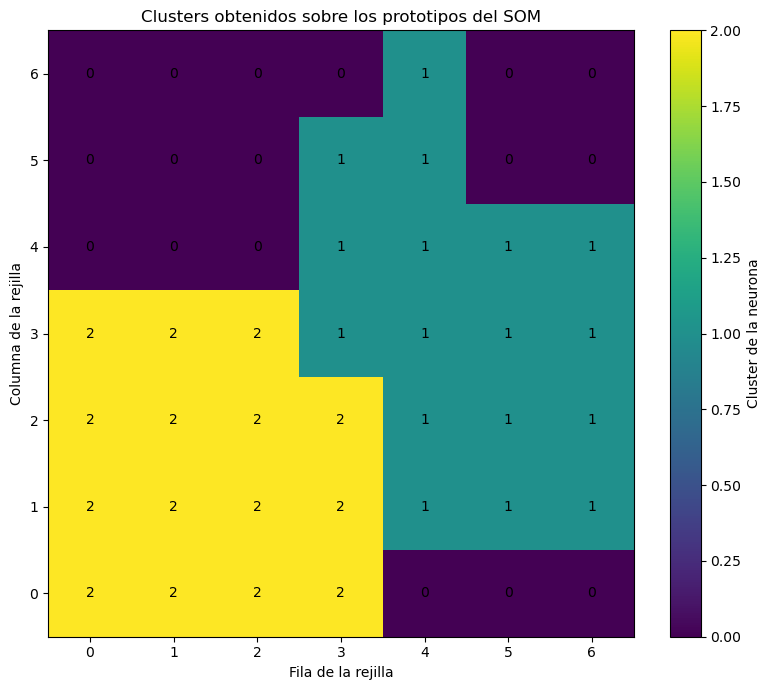

In [18]:
plt.figure(figsize=(8, 7))
plt.imshow(selected_neuron_clusters.T, origin="lower", aspect="auto")

for i in range(selected_map_x):
    for j in range(selected_map_y):
        plt.text(
            i, j,
            int(selected_neuron_clusters[i, j]),
            ha="center",
            va="center",
            fontsize=10
        )

plt.colorbar(label="Cluster de la neurona")
plt.xlabel("Fila de la rejilla")
plt.ylabel("Columna de la rejilla")
plt.title("Clusters obtenidos sobre los prototipos del SOM")
plt.tight_layout()
plt.show()


## 10. Visualización de la partición con PCA

El SOM se ajusta utilizando las 13 variables estandarizadas. PCA se utiliza únicamente para proyectar las observaciones a dos dimensiones y visualizar la partición final.


In [19]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(
    "Varianza explicada por PC1 + PC2:",
    round(pca.explained_variance_ratio_.sum(), 3)
)


Varianza explicada por PC1 + PC2: 0.554


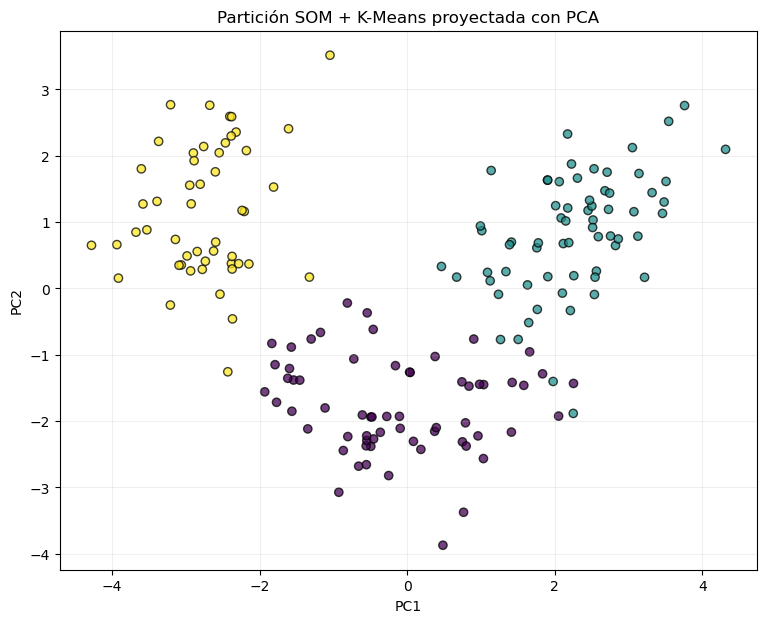

In [20]:
plt.figure(figsize=(9, 7))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=selected_labels,
    alpha=0.75,
    edgecolor="black"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Partición SOM + K-Means proyectada con PCA")
plt.grid(alpha=0.2)
plt.show()


## 11. Interpretación de los clusters


In [21]:
X_with_cluster = X.copy()
X_with_cluster["cluster"] = selected_labels

cluster_profiles = (
    X_with_cluster
    .groupby("cluster")
    .mean()
)

cluster_profiles


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
cluster,,,,,,,,,,,,,
0,12.242857,1.928571,2.248413,20.226984,91.47619,2.244286,2.037302,0.365556,1.565873,2.975397,1.057079,2.781746,502.238095
1,13.624769,1.954769,2.435538,17.373846,108.60000,2.819692,2.961692,0.290154,1.949385,5.379538,1.069538,3.149077,1079.753846
2,13.144000,3.346200,2.425600,21.330000,98.64000,1.677200,0.807000,0.450400,1.156400,7.264400,0.686200,1.698800,622.440000


### 11.1. Perfiles estandarizados


In [22]:
scaled_profiles = (
    pd.DataFrame(X_scaled, columns=X.columns)
    .assign(cluster=selected_labels)
    .groupby("cluster")
    .mean()
)

scaled_profiles.T


cluster,0,1,2
alcohol,-0.936035,0.770992,0.177115
malic_acid,-0.366046,-0.342529,0.906507
ash,-0.431711,0.252298,0.215969
alcalinity_of_ash,0.219821,-0.636934,0.551040
magnesium,-0.580340,0.621980,-0.077345
total_phenols,-0.081441,0.840551,-0.990100
flavanoids,0.008064,0.936121,-1.227118
nonflavanoid_phenols,0.029827,-0.577745,0.713487
proanthocyanins,-0.043847,0.628097,-0.761279
color_intensity,-0.900911,0.139049,0.954384


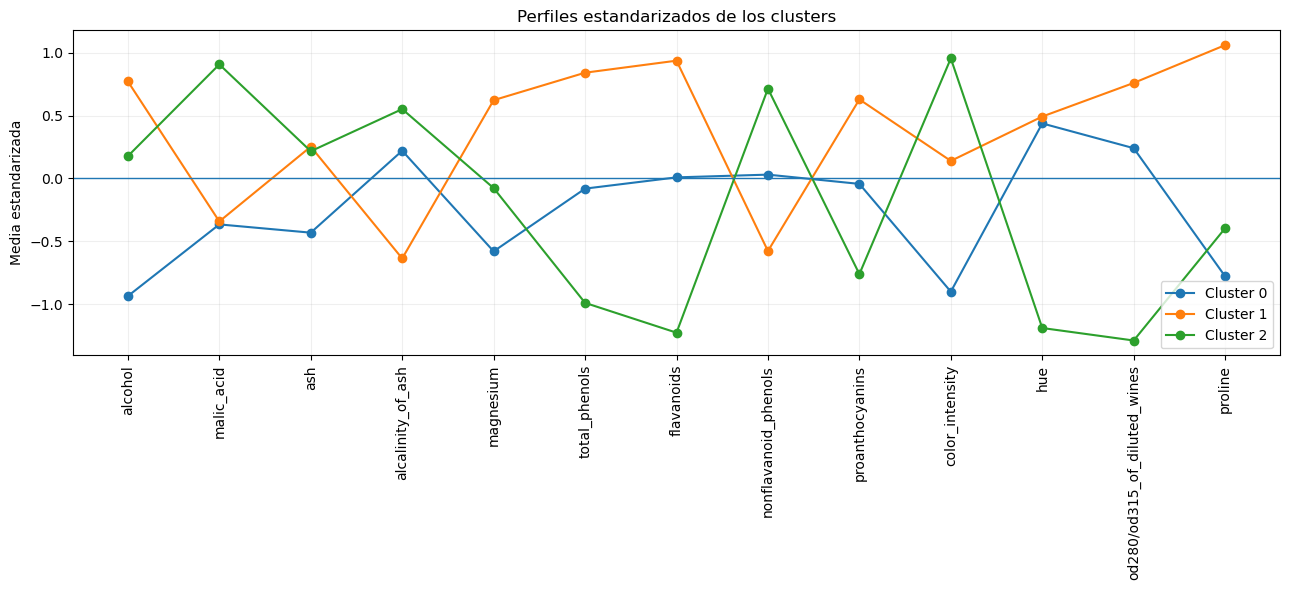

In [23]:
plt.figure(figsize=(13, 6))

for cluster_id in scaled_profiles.index:
    plt.plot(
        scaled_profiles.columns,
        scaled_profiles.loc[cluster_id],
        marker="o",
        label=f"Cluster {cluster_id}"
    )

plt.axhline(0, linewidth=1)
plt.xticks(rotation=90)
plt.ylabel("Media estandarizada")
plt.title("Perfiles estandarizados de los clusters")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


## 12. Comparación externa con las clases reales

Hasta este punto las clases reales no han participado en el entrenamiento del SOM, la selección de hiperparámetros ni el agrupamiento de los prototipos.

Ahora se utilizan únicamente como referencia externa mediante ARI y NMI.


In [24]:
external_metrics = pd.DataFrame({
    "ARI ↑": [adjusted_rand_score(y, selected_labels)],
    "NMI ↑": [normalized_mutual_info_score(y, selected_labels)]
}, index=["SOM + K-Means"])

external_metrics.round(3)


,ARI ↑,NMI ↑
SOM + K-Means,0.863,0.851


## 13. Lectura final

En este ejemplo, SOM se utiliza primero para aprender una representación topológica mediante prototipos. Posteriormente, K-Means agrupa esos prototipos para obtener una partición explícita.

La configuración se selecciona mediante un ranking multicriterio basado en SSE, Silhouette, Davies–Bouldin y Calinski–Harabasz.

Las clases reales del dataset Wine no participan en la selección del modelo; únicamente se utilizan al final como evaluación externa.
